In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [16]:
#Read the dataset
# Go up one level, then into the data folder
df = pd.read_csv(r"C:\Users\pendi\2-1-ML\PLACEMENT PREDICTION SYSTEM\data\placement_predict_50k Dataset_final (1).csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (50000, 32)


,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly,Salary Package
0,1,Male,Ahmedabad,Tier2,ECE,Networking,No,No,6.02,6.54,...,0,66.7,2.2,49.4,47.8,0,Low,0,0,0.00
1,2,Female,Mumbai,Tier2,ECE,DataScience,Yes,Yes,5.84,5.12,...,0,48.2,2.4,26.7,25.8,0,Low,0,0,0.00
2,3,Male,Kolkata,Tier2,IT,DataScience,Yes,No,4.91,5.29,...,0,73.8,2.8,67.7,41.5,0,Low,1,0,3.89
3,4,Male,Jaipur,Tier1,CS,AI,No,No,7.67,8.03,...,0,69.8,2.7,66.9,48.0,0,Mid,1,0,8.37
4,5,Male,Pune,Tier2,IT,DataScience,Yes,No,8.14,8.97,...,1,73.1,2.1,71.7,61.7,1,High,1,0,18.99


## Select X and y from dataset

In [17]:
X = df[["CGPA"]]
y = df["Salary Package"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50000, 1)
y shape: (50000,)


## Use placed students only

There are 32,924 placed students with complete salary data

In [18]:
placed_df = df[df["Salary Package"] > 0].copy()

print("Placed students with Salary Package > 0:", len(placed_df))

Placed students with Salary Package > 0: 32924


In [19]:
X = placed_df[["CGPA"]]
y = placed_df["Salary Package"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (32924, 1)
y shape: (32924,)


## Split the dataset into training and testing sets

In [20]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 26339
Testing samples : 6585


In [21]:
model = LinearRegression()

#Traing the model with training data
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[4.11]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['CGPA']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-18.42
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [22]:
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])

Intercept: -18.41694534995241
Coefficient: 4.110017173036385


In [23]:
#Predicting the salary package for training data

y_train_pred = model.predict(X_train)

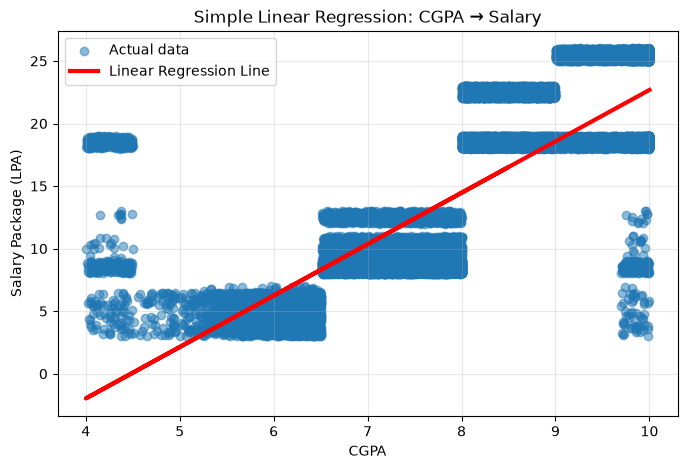

In [24]:
plt.figure(figsize=(8, 5))
plt.scatter(
    X_train["CGPA"],
    y_train,
    alpha=0.5,
    label="Actual data"
)

plt.plot(
    X_train["CGPA"],
    y_train_pred,
    color="red",
    linewidth=3,
    label="Linear Regression Line"
)

plt.xlabel("CGPA")
plt.ylabel("Salary Package (LPA)")
plt.title("Simple Linear Regression: CGPA → Salary")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Here red line goes upward from left to right.

That means:

1. As CGPA increases, the model predicts a higher salary package on average.

2. So there is a positive relationship between CGPA and predicted salary

The blue dots are the actual salary packages of students. The red line is the salary predicted using only CGPA. 

The upward slope indicates that students with higher CGPA tend to have higher predicted salaries. However, the large spread of blue points around the line shows that CGPA alone cannot completely explain salary variation.

  This is why we later move from Simple Linear Regression to Multiple Linear Regression by adding other relevant features

In [25]:
#predicting the salary package for testing data
y_test_pred = model.predict(X_test)

In [26]:
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R²  :", r2)

MSE : 18.30670578432481
RMSE: 4.278633635207017
MAE : 3.3848573025333004
R²  : 0.6080779825809519


In [27]:
## Sample CGPA (replacing interactive input for automated execution)
new_cgpa = 7.5

## Predict salary
predicted_salary = model.predict([[new_cgpa]])[0]
print(f"Predicted Salary Package: {predicted_salary:.2f} LPA")


Predicted Salary Package: 12.41 LPA


c:\Users\pendi\2-1-ML\PLACEMENT PREDICTION SYSTEM\.MLvenv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
